# CS5100 Capstone — Simulated Annealing: Reproduction & Extension
## Varun Agarwal | Spring 2026

**Paper:** Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). *Optimization by Simulated Annealing.* Science, 220(4598), 671-680.

**Project scope:**
- Reproduce SA on 3 combinatorial optimization domains: **0/1 Knapsack**, **TSP**, and **Graph Coloring**
- Compare 3 cooling schedules: **Geometric** (T×α), **Linear** (T-δ), **Logarithmic** (T₀/log(1+k))
- Investigate **MCMC/Metropolis-style** vs **random** neighborhood generation
- **Hill climbing** baseline for comparison
- 15 independent runs per configuration for statistical significance

## 0. Setup & Imports

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# reproducibility
random.seed(42)
np.random.seed(42)

NUM_RUNS = 15  # runs per configuration

## 1. Core SA Framework

One generic SA function that works for any problem domain — just pass in the cost function and neighbor generator.
This is the Metropolis acceptance criterion from statistical mechanics: accept worse solutions with probability exp(-Δ/T).

In [2]:
def simulated_annealing(init_solution, cost_fn, neighbor_fn,
                        cooling='geometric', T0=1000, alpha=0.995,
                        max_iter=15000, minimize=True, log_every=100):
    """
    Generic SA that works for any problem.
    Just pass in cost function and neighbor generator.

    cooling: 'geometric', 'linear', or 'logarithmic'
    minimize: True if we want to minimize cost (TSP, graph coloring),
              False if we want to maximize (knapsack)
    """
    current = init_solution
    curr_cost = cost_fn(current)
    best = current[:]  if isinstance(current, list) else current.copy()
    best_cost = curr_cost
    T = T0

    cost_history = []
    temp_history = []

    for k in range(1, max_iter + 1):
        neighbor = neighbor_fn(current)
        neigh_cost = cost_fn(neighbor)

        if minimize:
            delta = neigh_cost - curr_cost
        else:
            delta = curr_cost - neigh_cost

        # accept or reject
        if delta < 0:
            current = neighbor
            curr_cost = neigh_cost
        elif T > 1e-10:
            prob = math.exp(-delta / T) if delta / T < 500 else 0
            if random.random() < prob:
                current = neighbor
                curr_cost = neigh_cost

        # track best
        if (minimize and curr_cost < best_cost) or (not minimize and curr_cost > best_cost):
            best = current[:] if isinstance(current, list) else current.copy()
            best_cost = curr_cost

        # cooling schedule
        if cooling == 'geometric':
            T = T * alpha
        elif cooling == 'linear':
            T = T0 * max(0, 1 - k / max_iter)
        elif cooling == 'logarithmic':
            T = T0 / math.log(1 + k)

        if k % log_every == 0:
            cost_history.append(best_cost)
            temp_history.append(T)

    return best, best_cost, cost_history, temp_history


def hill_climbing(init_solution, cost_fn, neighbor_fn,
                  max_iter=15000, minimize=True, restarts=5):
    """Hill climbing baseline with random restarts."""
    overall_best = None
    overall_best_cost = float('inf') if minimize else float('-inf')

    for _ in range(restarts):
        current = init_solution() if callable(init_solution) else init_solution
        curr_cost = cost_fn(current)
        best = current[:] if isinstance(current, list) else current.copy()
        best_cost = curr_cost

        iters_per_restart = max_iter // restarts
        for _ in range(iters_per_restart):
            neighbor = neighbor_fn(current)
            neigh_cost = cost_fn(neighbor)

            if (minimize and neigh_cost < curr_cost) or (not minimize and neigh_cost > curr_cost):
                current = neighbor
                curr_cost = neigh_cost
                if (minimize and curr_cost < best_cost) or (not minimize and curr_cost > best_cost):
                    best = current[:] if isinstance(current, list) else current.copy()
                    best_cost = curr_cost

        if (minimize and best_cost < overall_best_cost) or (not minimize and best_cost > overall_best_cost):
            overall_best = best
            overall_best_cost = best_cost

    return overall_best, overall_best_cost

print("SA framework loaded.")

SA framework loaded.


## 2. Domain 1: 0/1 Knapsack Problem

Testing on FSU benchmark instances (P01, P02, P06, P07, P08).
- **Random neighbor**: flip a random bit (include/exclude item)
- **MCMC neighbor**: bias flips toward items with better value/weight ratio

In [3]:
# FSU benchmark instances
KNAPSACK_INSTANCES = {
    'P01': {
        'weights': [23, 31, 29, 44, 53, 38, 63, 85, 89, 82],
        'values':  [92, 57, 49, 68, 60, 43, 67, 84, 87, 72],
        'capacity': 165,
        'optimal': 309
    },
    'P02': {
        'weights': [12, 7, 11, 8, 9],
        'values':  [24, 13, 23, 15, 16],
        'capacity': 26,
        'optimal': 51
    },
    'P06': {
        'weights': [56, 59, 80, 64, 75, 17],
        'values':  [50, 50, 64, 46, 50, 5],
        'capacity': 190,
        'optimal': 150
    },
    'P07': {
        'weights': [31, 10, 20, 19, 4, 3, 6],
        'values':  [70, 20, 39, 37, 7, 5, 10],
        'capacity': 50,
        'optimal': 107
    },
    'P08': {
        'weights': [25, 35, 45, 5, 25, 3, 2, 2],
        'values':  [350, 400, 450, 20, 70, 8, 5, 5],
        'capacity': 104,
        'optimal': 900
    }
}

def make_knapsack_fns(weights, values, capacity):
    """create cost and neighbor functions for a knapsack instance"""
    n = len(weights)

    def cost_fn(sol):
        w = sum(wi * xi for wi, xi in zip(weights, sol))
        v = sum(vi * xi for vi, xi in zip(values, sol))
        if w > capacity:
            return -9999  # penalty for infeasible
        return v

    def random_neighbor(sol):
        neighbor = sol[:]
        idx = random.randint(0, n - 1)
        neighbor[idx] = 1 - neighbor[idx]
        # if over capacity, drop random items until feasible
        while sum(w * x for w, x in zip(weights, neighbor)) > capacity:
            ones = [i for i in range(n) if neighbor[i] == 1]
            if not ones:
                break
            neighbor[random.choice(ones)] = 0
        return neighbor

    def mcmc_neighbor(sol):
        """MCMC-style: bias toward flipping items with better value/weight ratio"""
        neighbor = sol[:]
        n = len(sol)
        # compute value density for each item
        ratios = [v / w if w > 0 else 0 for v, w in zip(values, weights)]

        # if adding items, prefer high ratio; if removing, prefer low ratio
        if random.random() < 0.5:
            # try to add an item (prefer high value/weight)
            zeros = [i for i in range(n) if sol[i] == 0]
            if zeros:
                probs = np.array([ratios[i] for i in zeros])
                probs = probs / probs.sum() if probs.sum() > 0 else np.ones(len(zeros)) / len(zeros)
                idx = np.random.choice(zeros, p=probs)
                neighbor[idx] = 1
        else:
            # try to remove an item (prefer low value/weight)
            ones = [i for i in range(n) if sol[i] == 1]
            if ones:
                probs = np.array([1 / (ratios[i] + 0.01) for i in ones])
                probs = probs / probs.sum()
                idx = np.random.choice(ones, p=probs)
                neighbor[idx] = 0

        # fix capacity
        while sum(w * x for w, x in zip(weights, neighbor)) > capacity:
            ones = [i for i in range(n) if neighbor[i] == 1]
            if not ones:
                break
            neighbor[random.choice(ones)] = 0
        return neighbor

    def random_init():
        sol = [0] * n
        indices = list(range(n))
        random.shuffle(indices)
        for i in indices:
            sol[i] = 1
            if sum(w * x for w, x in zip(weights, sol)) > capacity:
                sol[i] = 0
        return sol

    return cost_fn, random_neighbor, mcmc_neighbor, random_init



### Run Knapsack Experiments

In [4]:
def run_knapsack_experiments():
    print("=" * 70)
    print("DOMAIN 1: 0/1 KNAPSACK (FSU Benchmarks)")
    print("=" * 70)

    num_runs = 15
    cooling_schedules = ['geometric', 'linear', 'logarithmic']

    # store all results for plotting
    all_results = {}

    for name, inst in KNAPSACK_INSTANCES.items():
        print(f"\n--- {name}: {len(inst['weights'])} items, capacity={inst['capacity']}, optimal={inst['optimal']} ---")
        all_results[name] = {}

        for cooling in cooling_schedules:
            for neigh_type in ['random', 'mcmc']:
                cost_fn, rand_neigh, mcmc_neigh, rand_init = make_knapsack_fns(
                    inst['weights'], inst['values'], inst['capacity']
                )
                neigh_fn = mcmc_neigh if neigh_type == 'mcmc' else rand_neigh

                scores = []
                for _ in range(num_runs):
                    init = rand_init()
                    _, best_cost, _, _ = simulated_annealing(
                        init, cost_fn, neigh_fn,
                        cooling=cooling, T0=500, alpha=0.995, max_iter=10000,
                        minimize=False
                    )
                    scores.append(best_cost)

                key = f"{cooling}_{neigh_type}"
                avg = np.mean(scores)
                std = np.std(scores)
                pct = (avg / inst['optimal']) * 100
                hits = sum(1 for s in scores if s == inst['optimal'])
                all_results[name][key] = {
                    'scores': scores, 'avg': avg, 'std': std,
                    'pct': pct, 'hits': hits
                }
                print(f"  {cooling:12s} ({neigh_type:6s}): avg={avg:.1f}  std={std:.1f}  "
                      f"pct_optimal={pct:.1f}%  hits_optimal={hits}/{num_runs}")

        # hill climbing baseline
        cost_fn, rand_neigh, _, rand_init = make_knapsack_fns(
            inst['weights'], inst['values'], inst['capacity']
        )
        hc_scores = []
        for _ in range(num_runs):
            _, best_cost = hill_climbing(rand_init, cost_fn, rand_neigh,
                                         max_iter=10000, minimize=False, restarts=5)
            hc_scores.append(best_cost)

        hc_avg = np.mean(hc_scores)
        hc_pct = (hc_avg / inst['optimal']) * 100
        all_results[name]['hill_climbing'] = {
            'scores': hc_scores, 'avg': hc_avg, 'pct': hc_pct
        }
        print(f"  {'hill_climb':12s}         : avg={hc_avg:.1f}  pct_optimal={hc_pct:.1f}%")

    return all_results


# ============================================================

ks_results = run_knapsack_experiments()

DOMAIN 1: 0/1 KNAPSACK (FSU Benchmarks)

--- P01: 10 items, capacity=165, optimal=309 ---
  geometric    (random): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  geometric    (mcmc  ): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  linear       (random): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  linear       (mcmc  ): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  logarithmic  (random): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  logarithmic  (mcmc  ): avg=309.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  hill_climb           : avg=291.5  pct_optimal=94.3%

--- P02: 5 items, capacity=26, optimal=51 ---
  geometric    (random): avg=51.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  geometric    (mcmc  ): avg=51.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  linear       (random): avg=51.0  std=0.0  pct_optimal=100.0%  hits_optimal=15/15
  linear       (mcmc  ): avg=51.0  std=0.0  pct_optimal=

## 3. Domain 2: Traveling Salesman Problem

Testing on TSPLIB instances: burma14 (14 cities), ulysses22 (22 cities), random30 (30 cities).
- **2-opt neighborhood**: reverse a segment of the tour
- **MCMC 2-opt**: bias toward reversing segments containing the longest edges

In [5]:
# TSPLIB instances (coordinates)
TSP_INSTANCES = {
    'burma14': {
        'coords': [
            (16.47, 96.10), (16.47, 94.44), (20.09, 92.54), (22.39, 93.37),
            (25.23, 97.24), (22.00, 96.05), (20.47, 97.02), (17.20, 96.29),
            (16.30, 97.38), (14.05, 98.12), (16.53, 97.38), (21.52, 95.59),
            (19.41, 97.13), (20.09, 94.55)
        ],
        'optimal': 30.88  # known optimal tour length
    },
    'ulysses22': {
        'coords': [
            (38.24, 20.42), (39.57, 26.15), (40.56, 25.32), (36.26, 23.12),
            (33.48, 10.54), (37.56, 12.19), (38.42, 13.11), (37.52, 20.44),
            (41.23, 9.10), (41.17, 13.05), (36.08, -5.21), (38.47, 15.13),
            (38.15, 15.35), (37.51, 15.17), (35.49, 14.32), (39.36, 19.56),
            (38.09, 24.36), (36.09, 23.00), (40.44, 13.57), (40.33, 14.15),
            (40.37, 14.23), (37.57, 22.56)
        ],
        'optimal': 75.31
    }
}

# also generate a random 48-city instance
def generate_random_tsp(n=30, seed=42):
    rng = np.random.RandomState(seed)
    coords = [(rng.uniform(0, 100), rng.uniform(0, 100)) for _ in range(n)]
    return coords

TSP_INSTANCES['random30'] = {
    'coords': generate_random_tsp(30),
    'optimal': None  # unknown, we'll compare methods against each other
}

def make_tsp_fns(coords):
    n = len(coords)
    # precompute distance matrix
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dx = coords[i][0] - coords[j][0]
            dy = coords[i][1] - coords[j][1]
            dist[i][j] = math.sqrt(dx*dx + dy*dy)

    def cost_fn(tour):
        total = 0
        for i in range(len(tour)):
            total += dist[tour[i]][tour[(i+1) % n]]
        return total

    def two_opt_neighbor(tour):
        """standard 2-opt: reverse a segment"""
        neighbor = tour[:]
        i = random.randint(0, n - 2)
        j = random.randint(i + 1, n - 1)
        neighbor[i:j+1] = reversed(neighbor[i:j+1])
        return neighbor

    def mcmc_neighbor(tour):
        """MCMC-style 2-opt: bias toward reversing segments with long edges"""
        # find edges and their lengths
        edge_lengths = []
        for i in range(n):
            d = dist[tour[i]][tour[(i+1) % n]]
            edge_lengths.append((d, i))

        # sort by length descending - pick from top half more often
        edge_lengths.sort(reverse=True)
        # pick one of the longest edges with higher probability
        weights = np.array([1.0 / (rank + 1) for rank in range(n)])
        weights /= weights.sum()
        idx = np.random.choice(n, p=weights)
        i = edge_lengths[idx][1]

        # pick second cut point
        j = random.randint(0, n - 1)
        while j == i:
            j = random.randint(0, n - 1)

        if i > j:
            i, j = j, i

        neighbor = tour[:]
        neighbor[i:j+1] = reversed(neighbor[i:j+1])
        return neighbor

    def random_init():
        tour = list(range(n))
        random.shuffle(tour)
        return tour

    return cost_fn, two_opt_neighbor, mcmc_neighbor, random_init, dist



### Run TSP Experiments

In [6]:
def run_tsp_experiments():
    print("\n" + "=" * 70)
    print("DOMAIN 2: TRAVELING SALESMAN PROBLEM")
    print("=" * 70)

    num_runs = 15
    cooling_schedules = ['geometric', 'linear', 'logarithmic']
    all_results = {}
    best_tours = {}

    for name, inst in TSP_INSTANCES.items():
        coords = inst['coords']
        n = len(coords)
        opt = inst['optimal']
        print(f"\n--- {name}: {n} cities" + (f", optimal={opt}" if opt else "") + " ---")

        cost_fn, two_opt, mcmc_neigh, rand_init, dist_mat = make_tsp_fns(coords)
        all_results[name] = {}

        for cooling in cooling_schedules:
            for neigh_type in ['random', 'mcmc']:
                neigh_fn = mcmc_neigh if neigh_type == 'mcmc' else two_opt

                scores = []
                best_tour_this = None
                best_cost_this = float('inf')

                for _ in range(num_runs):
                    init = rand_init()
                    tour, cost, _, _ = simulated_annealing(
                        init, cost_fn, neigh_fn,
                        cooling=cooling, T0=500, alpha=0.999, max_iter=12000,
                        minimize=True
                    )
                    scores.append(cost)
                    if cost < best_cost_this:
                        best_cost_this = cost
                        best_tour_this = tour

                key = f"{cooling}_{neigh_type}"
                avg = np.mean(scores)
                std = np.std(scores)
                pct = (opt / avg * 100) if opt else None
                all_results[name][key] = {
                    'scores': scores, 'avg': avg, 'std': std,
                    'best': min(scores), 'pct': pct
                }

                if best_cost_this < best_tours.get(name, (None, float('inf')))[1]:
                    best_tours[name] = (best_tour_this, best_cost_this)

                pct_str = f"  pct_optimal={pct:.1f}%" if pct else ""
                print(f"  {cooling:12s} ({neigh_type:6s}): avg={avg:.2f}  std={std:.2f}  "
                      f"best={min(scores):.2f}{pct_str}")

        # hill climbing baseline
        hc_scores = []
        for _ in range(num_runs):
            _, best_cost = hill_climbing(rand_init, cost_fn, two_opt,
                                         max_iter=12000, minimize=True, restarts=5)
            hc_scores.append(best_cost)

        hc_avg = np.mean(hc_scores)
        pct_str = f"  pct_optimal={(opt/hc_avg*100):.1f}%" if opt else ""
        all_results[name]['hill_climbing'] = {
            'scores': hc_scores, 'avg': hc_avg, 'best': min(hc_scores)
        }
        print(f"  {'hill_climb':12s}         : avg={hc_avg:.2f}  best={min(hc_scores):.2f}{pct_str}")

    return all_results, best_tours


# ============================================================

tsp_results, best_tours = run_tsp_experiments()


DOMAIN 2: TRAVELING SALESMAN PROBLEM

--- burma14: 14 cities, optimal=30.88 ---
  geometric    (random): avg=30.90  std=0.08  best=30.88  pct_optimal=99.9%
  geometric    (mcmc  ): avg=30.92  std=0.12  best=30.88  pct_optimal=99.9%
  linear       (random): avg=37.20  std=2.09  best=31.81  pct_optimal=83.0%
  linear       (mcmc  ): avg=36.03  std=1.15  best=32.46  pct_optimal=85.7%
  logarithmic  (random): avg=38.25  std=0.96  best=36.27  pct_optimal=80.7%
  logarithmic  (mcmc  ): avg=35.97  std=1.33  best=32.32  pct_optimal=85.8%
  hill_climb           : avg=31.08  best=30.88  pct_optimal=99.4%

--- ulysses22: 22 cities, optimal=75.31 ---
  geometric    (random): avg=76.01  std=0.48  best=75.31  pct_optimal=99.1%
  geometric    (mcmc  ): avg=76.04  std=0.29  best=75.51  pct_optimal=99.0%
  linear       (random): avg=103.45  std=10.93  best=86.83  pct_optimal=72.8%
  linear       (mcmc  ): avg=102.65  std=8.03  best=90.05  pct_optimal=73.4%
  logarithmic  (random): avg=118.18  std=4.46

## 4. Domain 3: Graph Coloring

Testing on Petersen graph (10 nodes, χ=3), Queen5x5 (25 nodes, χ=5), and random graph (30 nodes).
- **Random neighbor**: pick any node, assign random color
- **MCMC neighbor**: specifically target nodes involved in conflicts, pick least-conflicting color

This is where MCMC neighborhoods show the biggest advantage — targeting conflict nodes is much smarter than random.

In [7]:
def make_petersen_graph():
    """Petersen graph: 10 nodes, chromatic number = 3"""
    adj = {
        0: [1,4,5], 1: [0,2,6], 2: [1,3,7], 3: [2,4,8], 4: [3,0,9],
        5: [0,7,8], 6: [1,8,9], 7: [2,5,9], 8: [3,5,6], 9: [4,6,7]
    }
    return adj, 10, 3, 'Petersen (n=10, χ=3)'

def make_queen5x5_graph():
    """Queen5x5: 25 nodes, chromatic number = 5
    nodes on a 5x5 grid, edges between nodes that share row, col, or diagonal
    """
    n = 25
    adj = {i: [] for i in range(n)}
    for i in range(n):
        r1, c1 = i // 5, i % 5
        for j in range(i+1, n):
            r2, c2 = j // 5, j % 5
            if r1 == r2 or c1 == c2 or abs(r1-r2) == abs(c1-c2):
                adj[i].append(j)
                adj[j].append(i)
    return adj, 25, 5, 'Queen5x5 (n=25, χ=5)'

def make_random_graph(n=30, edge_prob=0.3, seed=42):
    """random graph for testing"""
    rng = random.Random(seed)
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            if rng.random() < edge_prob:
                adj[i].append(j)
                adj[j].append(i)
    # estimate chromatic number using greedy coloring
    colors_used = {}
    for node in range(n):
        neighbor_colors = {colors_used[nb] for nb in adj[node] if nb in colors_used}
        c = 0
        while c in neighbor_colors:
            c += 1
        colors_used[node] = c
    chi_approx = max(colors_used.values()) + 1
    return adj, n, chi_approx, f'Random (n={n}, χ≈{chi_approx})'

def make_graph_color_fns(adj, n, num_colors):
    """create cost and neighbor functions for graph coloring"""

    def cost_fn(coloring):
        """count number of conflicts (adjacent nodes with same color)"""
        conflicts = 0
        counted = set()
        for i in range(n):
            for j in adj[i]:
                if j > i and coloring[i] == coloring[j]:
                    conflicts += 1
        return conflicts

    def random_neighbor(coloring):
        """pick a random node, change to a random color"""
        neighbor = coloring[:]
        node = random.randint(0, n - 1)
        new_color = random.randint(0, num_colors - 1)
        # make sure we actually change it
        while new_color == neighbor[node] and num_colors > 1:
            new_color = random.randint(0, num_colors - 1)
        neighbor[node] = new_color
        return neighbor

    def mcmc_neighbor(coloring):
        """MCMC-style: target conflicting nodes specifically"""
        neighbor = coloring[:]
        # find nodes involved in conflicts
        conflict_nodes = []
        for i in range(n):
            for j in adj[i]:
                if coloring[i] == coloring[j]:
                    conflict_nodes.append(i)
                    break

        if conflict_nodes:
            # pick a conflicting node
            node = random.choice(conflict_nodes)
        else:
            # no conflicts — pick any node
            node = random.randint(0, n - 1)

        # pick a color that minimizes conflicts for this node
        neighbor_colors = [coloring[nb] for nb in adj[node]]
        # find colors NOT used by neighbors
        available = [c for c in range(num_colors) if c not in neighbor_colors]

        if available:
            neighbor[node] = random.choice(available)
        else:
            # all colors conflict, pick least conflicting
            color_conflicts = {}
            for c in range(num_colors):
                color_conflicts[c] = sum(1 for nb in adj[node] if coloring[nb] == c)
            min_conf = min(color_conflicts.values())
            best_colors = [c for c, v in color_conflicts.items() if v == min_conf]
            neighbor[node] = random.choice(best_colors)

        return neighbor

    def random_init():
        return [random.randint(0, num_colors - 1) for _ in range(n)]

    return cost_fn, random_neighbor, mcmc_neighbor, random_init



### Run Graph Coloring Experiments

In [8]:
def run_graph_coloring_experiments():
    print("\n" + "=" * 70)
    print("DOMAIN 3: GRAPH COLORING")
    print("=" * 70)

    num_runs = 15
    cooling_schedules = ['geometric', 'linear', 'logarithmic']

    graphs = [make_petersen_graph(), make_queen5x5_graph(), make_random_graph()]
    all_results = {}

    for adj, n, num_colors, graph_name in graphs:
        print(f"\n--- {graph_name}, using {num_colors} colors ---")
        cost_fn, rand_neigh, mcmc_neigh, rand_init = make_graph_color_fns(adj, n, num_colors)
        all_results[graph_name] = {}

        for cooling in cooling_schedules:
            for neigh_type in ['random', 'mcmc']:
                neigh_fn = mcmc_neigh if neigh_type == 'mcmc' else rand_neigh

                scores = []
                successes = 0

                for _ in range(num_runs):
                    init = rand_init()
                    _, best_cost, _, _ = simulated_annealing(
                        init, cost_fn, neigh_fn,
                        cooling=cooling, T0=200, alpha=0.998, max_iter=15000,
                        minimize=True
                    )
                    scores.append(best_cost)
                    if best_cost == 0:
                        successes += 1

                key = f"{cooling}_{neigh_type}"
                avg = np.mean(scores)
                std = np.std(scores)
                all_results[graph_name][key] = {
                    'scores': scores, 'avg': avg, 'std': std,
                    'successes': successes
                }
                print(f"  {cooling:12s} ({neigh_type:6s}): avg_conflicts={avg:.2f}  "
                      f"std={std:.2f}  valid_colorings={successes}/{num_runs}")

        # hill climbing baseline
        hc_scores = []
        hc_successes = 0
        for _ in range(num_runs):
            _, best_cost = hill_climbing(rand_init, cost_fn, rand_neigh,
                                         max_iter=15000, minimize=True, restarts=5)
            hc_scores.append(best_cost)
            if best_cost == 0:
                hc_successes += 1

        all_results[graph_name]['hill_climbing'] = {
            'scores': hc_scores, 'avg': np.mean(hc_scores), 'successes': hc_successes
        }
        print(f"  {'hill_climb':12s}         : avg_conflicts={np.mean(hc_scores):.2f}  "
              f"valid_colorings={hc_successes}/{num_runs}")

    return all_results


# ============================================================

gc_results = run_graph_coloring_experiments()


DOMAIN 3: GRAPH COLORING

--- Petersen (n=10, χ=3), using 3 colors ---
  geometric    (random): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  geometric    (mcmc  ): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  linear       (random): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  linear       (mcmc  ): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  logarithmic  (random): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  logarithmic  (mcmc  ): avg_conflicts=0.00  std=0.00  valid_colorings=15/15
  hill_climb           : avg_conflicts=0.00  valid_colorings=15/15

--- Queen5x5 (n=25, χ=5), using 5 colors ---
  geometric    (random): avg_conflicts=0.53  std=1.36  valid_colorings=13/15
  geometric    (mcmc  ): avg_conflicts=1.20  std=2.04  valid_colorings=11/15
  linear       (random): avg_conflicts=13.13  std=1.67  valid_colorings=0/15
  linear       (mcmc  ): avg_conflicts=1.60  std=2.65  valid_colorings=11/15
  logarithmic  (random): avg_conflicts=16.33 

## 5. Convergence Analysis

Detailed single runs to visualize how each cooling schedule converges over iterations.
Also compares MCMC vs random neighborhood convergence on graph coloring.

In [9]:
def run_convergence_analysis():
    """run single detailed runs for convergence curve plots"""
    print("\n" + "=" * 70)
    print("CONVERGENCE ANALYSIS")
    print("=" * 70)

    results = {}

    # Knapsack P08 convergence
    inst = KNAPSACK_INSTANCES['P08']
    cost_fn, rand_neigh, mcmc_neigh, rand_init = make_knapsack_fns(
        inst['weights'], inst['values'], inst['capacity']
    )
    results['knapsack'] = {}
    for cooling in ['geometric', 'linear', 'logarithmic']:
        init = rand_init()
        _, _, history, temps = simulated_annealing(
            init, cost_fn, rand_neigh, cooling=cooling,
            T0=500, alpha=0.995, max_iter=10000, minimize=False, log_every=50
        )
        results['knapsack'][cooling] = history

    # TSP burma14 convergence
    coords = TSP_INSTANCES['burma14']['coords']
    cost_fn, two_opt, mcmc_neigh, rand_init, _ = make_tsp_fns(coords)
    results['tsp'] = {}
    for cooling in ['geometric', 'linear', 'logarithmic']:
        init = rand_init()
        _, _, history, _ = simulated_annealing(
            init, cost_fn, two_opt, cooling=cooling,
            T0=500, alpha=0.999, max_iter=12000, minimize=True, log_every=100
        )
        results['tsp'][cooling] = history

    # Graph coloring Petersen convergence
    adj, n, nc, _ = make_petersen_graph()
    cost_fn, rand_neigh, mcmc_neigh, rand_init = make_graph_color_fns(adj, n, nc)
    results['graph'] = {}
    for cooling in ['geometric', 'linear', 'logarithmic']:
        init = rand_init()
        _, _, history, _ = simulated_annealing(
            init, cost_fn, mcmc_neigh, cooling=cooling,
            T0=200, alpha=0.998, max_iter=15000, minimize=True, log_every=50
        )
        results['graph'][cooling] = history

    # MCMC vs Random comparison for graph coloring
    results['mcmc_comparison'] = {}
    for neigh_type, neigh_fn in [('random', rand_neigh), ('mcmc', mcmc_neigh)]:
        init = rand_init()
        _, _, history, _ = simulated_annealing(
            init, cost_fn, neigh_fn, cooling='geometric',
            T0=200, alpha=0.998, max_iter=15000, minimize=True, log_every=50
        )
        results['mcmc_comparison'][neigh_type] = history

    return results


# ============================================================

conv_results = run_convergence_analysis()


CONVERGENCE ANALYSIS


## 6. Statistical Tests

- **t-tests**: SA (geometric) vs Hill Climbing per knapsack instance
- **t-tests**: Random vs MCMC neighborhood for graph coloring
- **ANOVA**: Cooling schedule comparison for TSP (geometric vs linear vs logarithmic)

In [10]:
def run_statistical_tests(knapsack_results, tsp_results, gc_results):
    print("\n" + "=" * 70)
    print("STATISTICAL ANALYSIS (t-tests)")
    print("=" * 70)

    test_results = []

    # SA geometric vs hill climbing for each knapsack instance
    print("\n--- SA (geometric) vs Hill Climbing ---")
    for name in KNAPSACK_INSTANCES:
        sa_scores = knapsack_results[name]['geometric_random']['scores']
        hc_scores = knapsack_results[name]['hill_climbing']['scores']
        t_stat, p_val = stats.ttest_ind(sa_scores, hc_scores)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  Knapsack {name}: t={t_stat:.3f}, p={p_val:.4f} {sig}")
        test_results.append((f'KS-{name}', t_stat, p_val, sig))

    # SA geometric random vs SA geometric MCMC for graph coloring
    print("\n--- Random vs MCMC Neighborhood (Graph Coloring) ---")
    for graph_name in gc_results:
        rand_scores = gc_results[graph_name]['geometric_random']['scores']
        mcmc_scores = gc_results[graph_name]['geometric_mcmc']['scores']
        t_stat, p_val = stats.ttest_ind(rand_scores, mcmc_scores)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  {graph_name}: t={t_stat:.3f}, p={p_val:.4f} {sig}")
        test_results.append((graph_name, t_stat, p_val, sig))

    # cooling schedule comparison (geometric vs linear vs logarithmic) for TSP
    print("\n--- Cooling Schedule Comparison (TSP, random neighbor) ---")
    for name in TSP_INSTANCES:
        geo = tsp_results[name]['geometric_random']['scores']
        lin = tsp_results[name]['linear_random']['scores']
        log = tsp_results[name]['logarithmic_random']['scores']

        # ANOVA
        f_stat, p_val = stats.f_oneway(geo, lin, log)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  TSP {name}: F={f_stat:.3f}, p={p_val:.4f} {sig}")

    return test_results


# ============================================================

stat_results = run_statistical_tests(ks_results, tsp_results, gc_results)


STATISTICAL ANALYSIS (t-tests)

--- SA (geometric) vs Hill Climbing ---
  Knapsack P01: t=3.016, p=0.0054 **
  Knapsack P02: t=nan, p=nan ns
  Knapsack P06: t=1.468, p=0.1534 ns
  Knapsack P07: t=nan, p=nan ns
  Knapsack P08: t=1.164, p=0.2541 ns

--- Random vs MCMC Neighborhood (Graph Coloring) ---
  Petersen (n=10, χ=3): t=nan, p=nan ns
  Queen5x5 (n=25, χ=5): t=-1.018, p=0.3176 ns
  Random (n=30, χ≈7): t=nan, p=nan ns

--- Cooling Schedule Comparison (TSP, random neighbor) ---
  TSP burma14: F=124.988, p=0.0000 ***
  TSP ulysses22: F=137.922, p=0.0000 ***
  TSP random30: F=475.884, p=0.0000 ***


## 7. Results Visualization

9 plots covering all experiments:

In [11]:
# color scheme for cooling schedules
colors_map = {
    'geometric': '#2196F3',   # blue
    'linear': '#FF9800',      # orange
    'logarithmic': '#4CAF50'  # green
}

In [12]:
# shared color scheme
colors_map = {
    'geometric': '#2196F3',
    'linear': '#FF9800',
    'logarithmic': '#4CAF50'
}

configs = [
    ('geometric_random', 'Geo+Rand', '#2196F3'),
    ('geometric_mcmc', 'Geo+MCMC', '#1565C0'),
    ('linear_random', 'Lin+Rand', '#FF9800'),
    ('linear_mcmc', 'Lin+MCMC', '#E65100'),
    ('logarithmic_random', 'Log+Rand', '#4CAF50'),
    ('logarithmic_mcmc', 'Log+MCMC', '#2E7D32'),
    ('hill_climbing', 'Hill Climb', '#F44336'),
]

### Plot 1: Knapsack Solution Quality

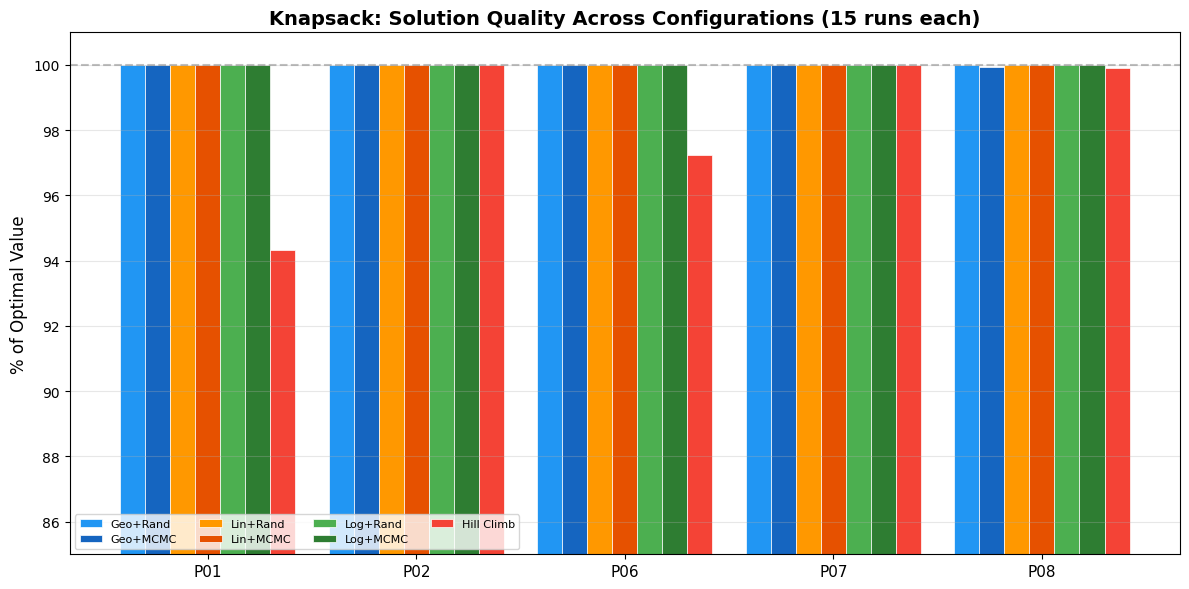

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
instances = list(KNAPSACK_INSTANCES.keys())
x = np.arange(len(instances))
width = 0.12

for i, (key, label, color) in enumerate(configs):
    pcts = [ks_results[name][key]['pct'] for name in instances]
    ax.bar(x + i * width - 3*width, pcts, width, label=label, color=color, edgecolor='white', linewidth=0.5)

ax.set_ylabel('% of Optimal Value', fontsize=12)
ax.set_title('Knapsack: Solution Quality Across Configurations (15 runs each)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(instances, fontsize=11)
ax.legend(fontsize=8, ncol=4, loc='lower left')
ax.set_ylim(85, 101)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 2: TSP Tour Length Comparison

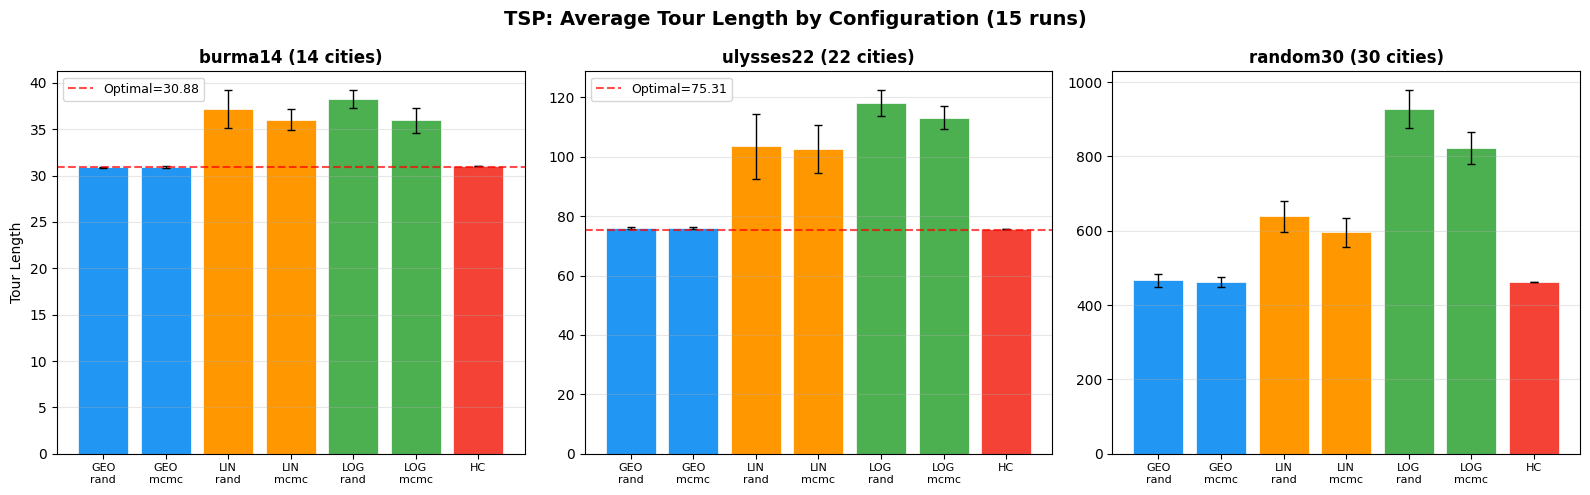

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, name in enumerate(TSP_INSTANCES):
    ax = axes[idx]
    data = tsp_results[name]
    labels, means, stds, bar_colors = [], [], [], []

    for cooling in ['geometric', 'linear', 'logarithmic']:
        for neigh in ['random', 'mcmc']:
            key = f'{cooling}_{neigh}'
            labels.append(f'{cooling[:3].upper()}\n{neigh[:4]}')
            means.append(data[key]['avg'])
            stds.append(data[key]['std'])
            bar_colors.append(colors_map[cooling])

    labels.append('HC')
    means.append(data['hill_climbing']['avg'])
    stds.append(0)
    bar_colors.append('#F44336')

    x_pos = np.arange(len(labels))
    ax.bar(x_pos, means, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.errorbar(x_pos, means, yerr=stds, fmt='none', ecolor='black', capsize=3, linewidth=1)

    opt = TSP_INSTANCES[name]['optimal']
    if opt:
        ax.axhline(y=opt, color='red', linestyle='--', alpha=0.7, label=f'Optimal={opt}')
        ax.legend(fontsize=9)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{name} ({len(TSP_INSTANCES[name]["coords"])} cities)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Tour Length' if idx == 0 else '')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('TSP: Average Tour Length by Configuration (15 runs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 3: Best Tour Visualizations

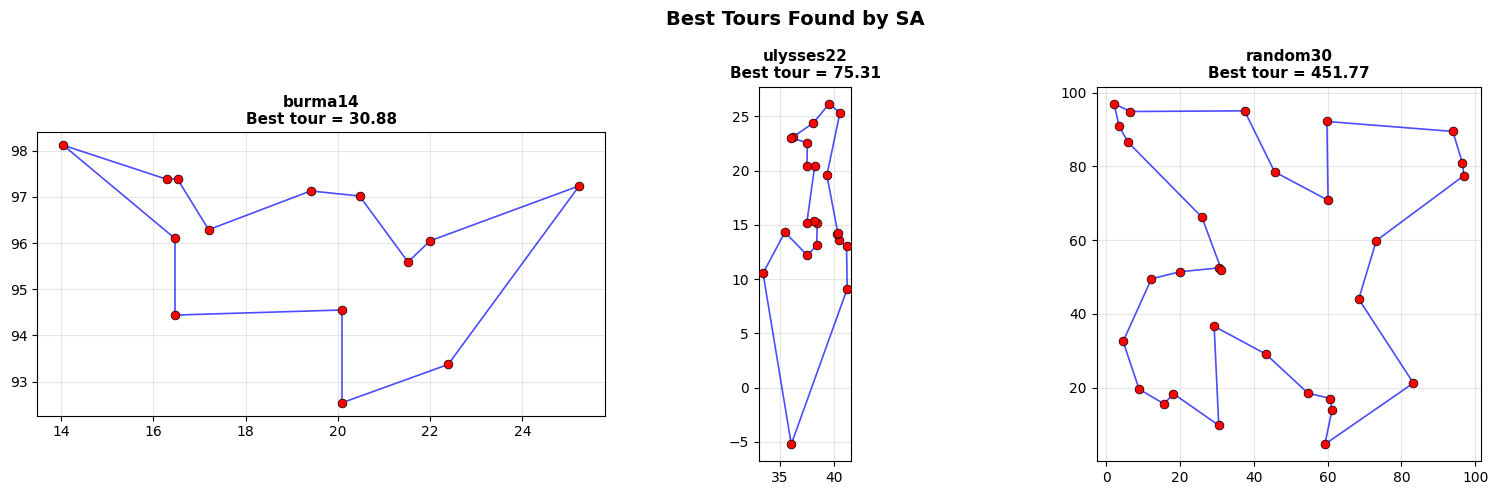

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, name in enumerate(TSP_INSTANCES):
    ax = axes[idx]
    coords = TSP_INSTANCES[name]['coords']
    if name in best_tours:
        tour, cost = best_tours[name]
        for i in range(len(tour)):
            c1 = coords[tour[i]]
            c2 = coords[tour[(i+1) % len(tour)]]
            ax.plot([c1[0], c2[0]], [c1[1], c2[1]], 'b-', linewidth=1.2, alpha=0.7)
        xs = [coords[i][0] for i in range(len(coords))]
        ys = [coords[i][1] for i in range(len(coords))]
        ax.scatter(xs, ys, c='red', s=40, zorder=5, edgecolors='black', linewidths=0.5)
        ax.set_title(f'{name}\nBest tour = {cost:.2f}', fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.suptitle('Best Tours Found by SA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 4: Graph Coloring Success Rates

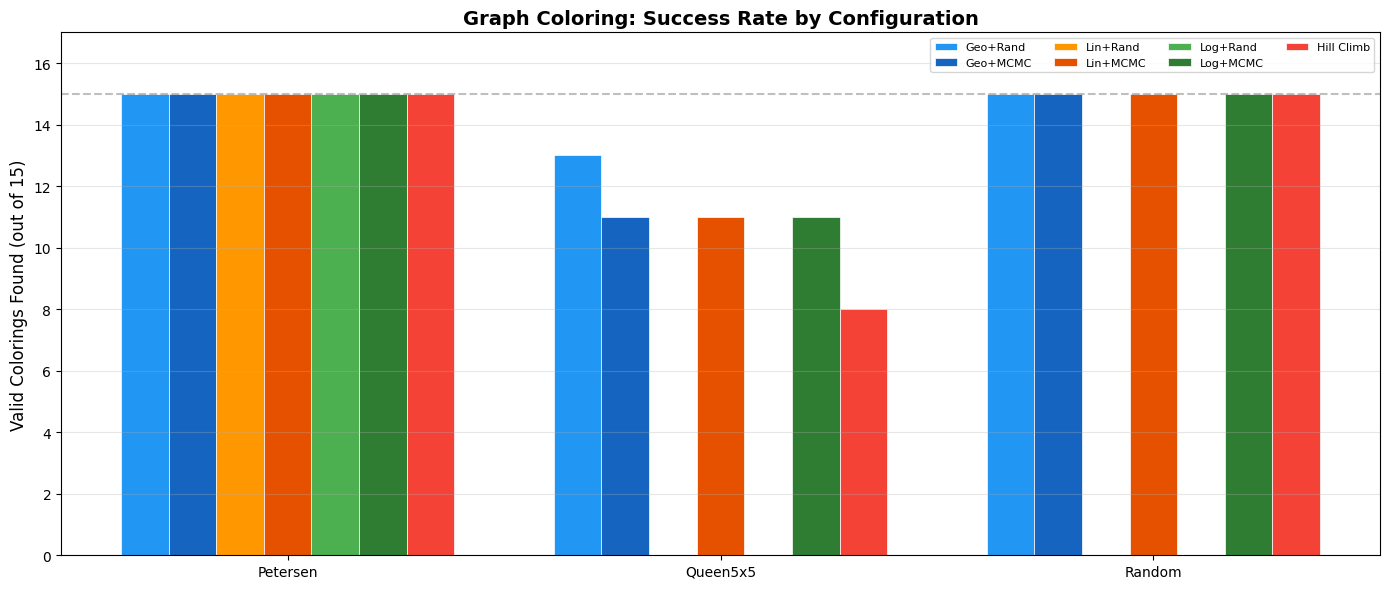

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
graph_names = list(gc_results.keys())
x = np.arange(len(graph_names))
width = 0.11

for i, (key, label, color) in enumerate(configs):
    vals = [gc_results[gn][key]['successes'] if key in gc_results[gn] else 0 for gn in graph_names]
    ax.bar(x + i * width - 3*width, vals, width, label=label, color=color, edgecolor='white', linewidth=0.5)

ax.set_ylabel('Valid Colorings Found (out of 15)', fontsize=12)
ax.set_title('Graph Coloring: Success Rate by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([gn.split('(')[0].strip() for gn in graph_names], fontsize=10)
ax.legend(fontsize=8, ncol=4, loc='upper right')
ax.set_ylim(0, 17)
ax.axhline(y=15, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 5: Graph Coloring Average Conflicts

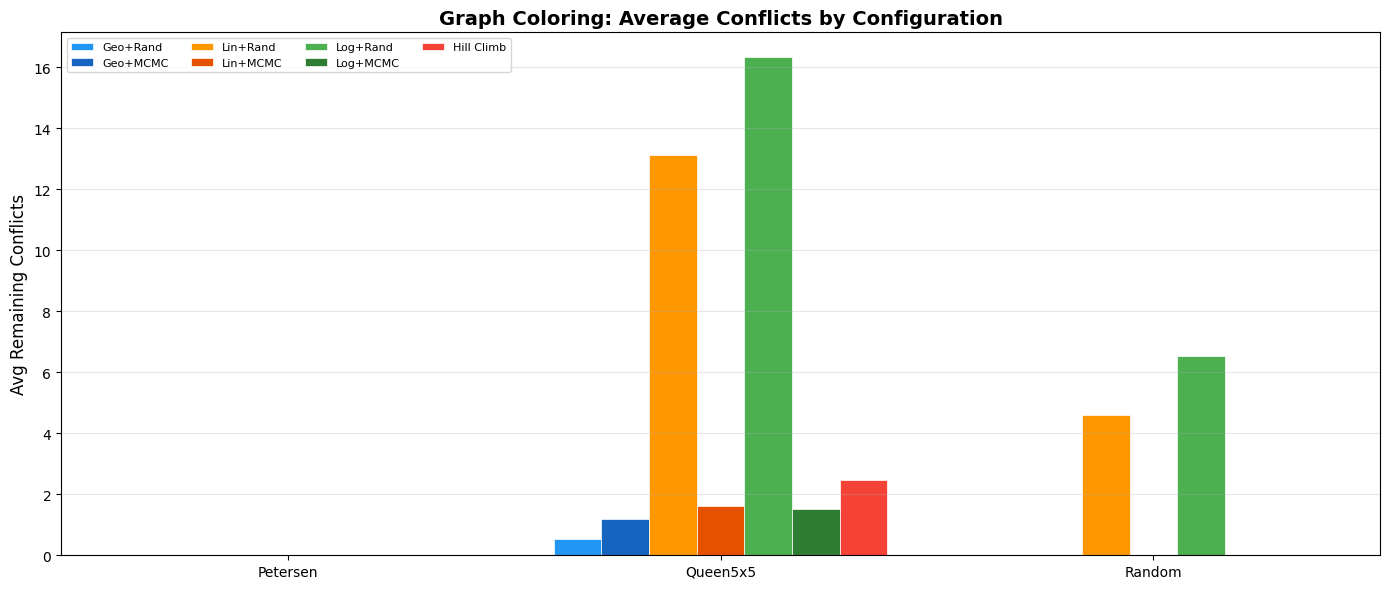

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

for i, (key, label, color) in enumerate(configs):
    vals = [gc_results[gn][key]['avg'] if key in gc_results[gn] else 0 for gn in graph_names]
    ax.bar(x + i * width - 3*width, vals, width, label=label, color=color, edgecolor='white', linewidth=0.5)

ax.set_ylabel('Avg Remaining Conflicts', fontsize=12)
ax.set_title('Graph Coloring: Average Conflicts by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([gn.split('(')[0].strip() for gn in graph_names], fontsize=10)
ax.legend(fontsize=8, ncol=4, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 6: Convergence Curves by Cooling Schedule

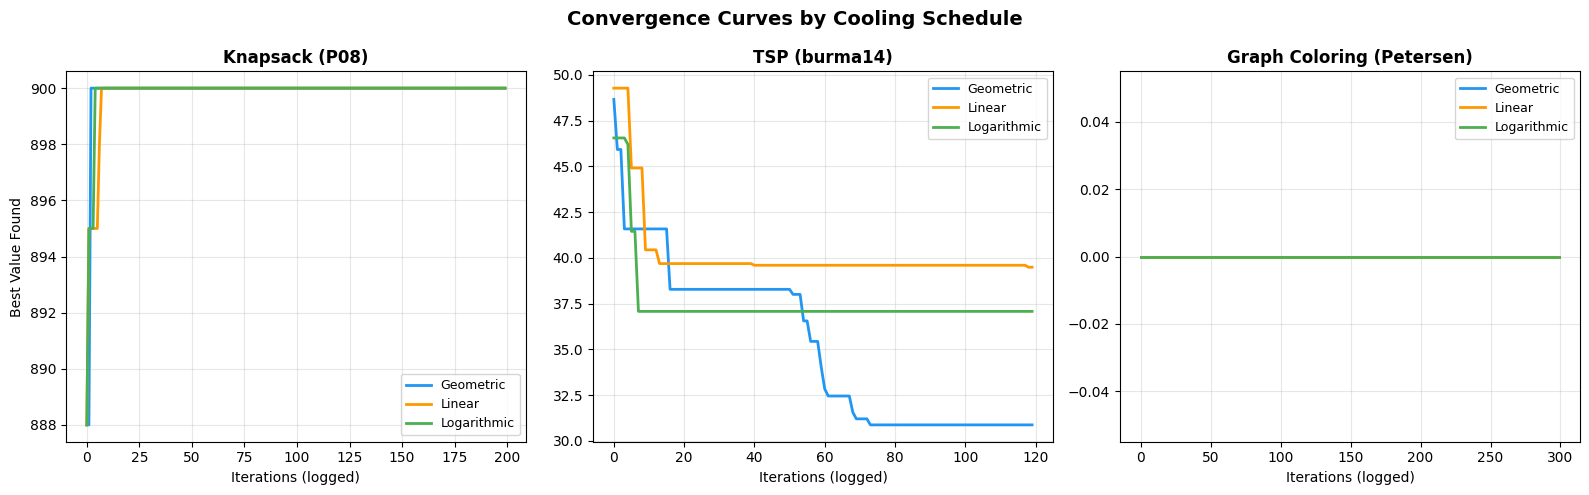

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Knapsack (P08)', 'TSP (burma14)', 'Graph Coloring (Petersen)']
domains = ['knapsack', 'tsp', 'graph']
y_labels = ['Best Value Found', 'Best Tour Length', 'Best # Conflicts']

for idx, (domain, title, ylabel) in enumerate(zip(domains, titles, y_labels)):
    ax = axes[idx]
    for cooling, color in colors_map.items():
        if cooling in conv_results[domain]:
            history = conv_results[domain][cooling]
            ax.plot(range(len(history)), history, label=cooling.capitalize(), color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Iterations (logged)')
    ax.set_ylabel(ylabel if idx == 0 else '')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Convergence Curves by Cooling Schedule', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 7: MCMC vs Random Neighborhood (Graph Coloring)

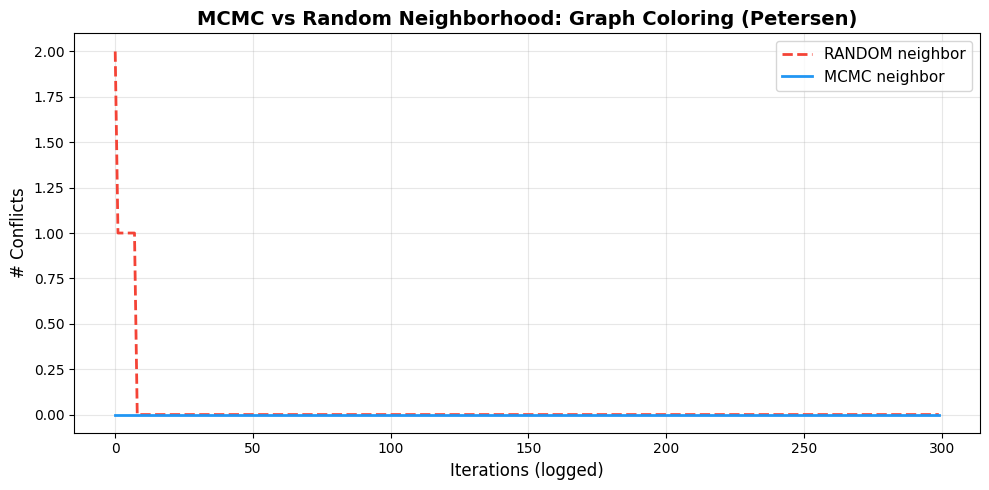

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

for neigh_type, color, ls in [('random', '#F44336', '--'), ('mcmc', '#2196F3', '-')]:
    history = conv_results['mcmc_comparison'][neigh_type]
    ax.plot(range(len(history)), history, label=f'{neigh_type.upper()} neighbor', color=color, linewidth=2, linestyle=ls)

ax.set_title('MCMC vs Random Neighborhood: Graph Coloring (Petersen)', fontsize=14, fontweight='bold')
ax.set_xlabel('Iterations (logged)', fontsize=12)
ax.set_ylabel('# Conflicts', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 8: Scalability — SA vs Hill Climbing

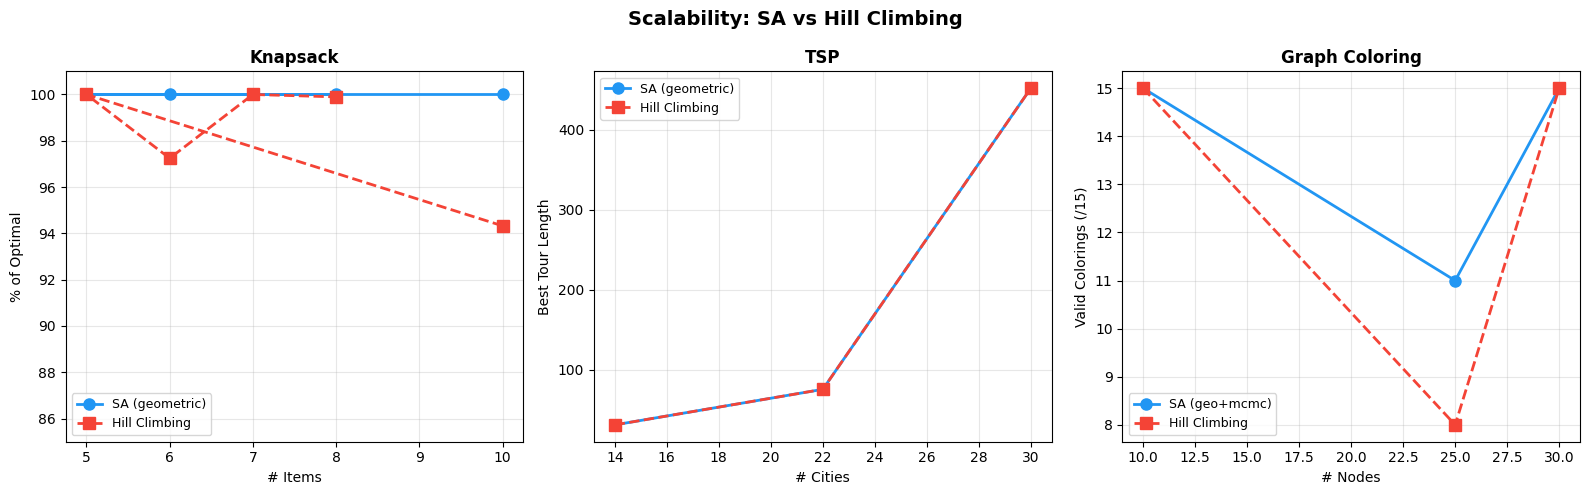

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Knapsack
ax = axes[0]
sizes = [len(KNAPSACK_INSTANCES[n]['weights']) for n in KNAPSACK_INSTANCES]
geo_pcts = [ks_results[n]['geometric_random']['pct'] for n in KNAPSACK_INSTANCES]
hc_pcts = [ks_results[n]['hill_climbing']['pct'] for n in KNAPSACK_INSTANCES]
ax.plot(sizes, geo_pcts, 'o-', color='#2196F3', linewidth=2, markersize=8, label='SA (geometric)')
ax.plot(sizes, hc_pcts, 's--', color='#F44336', linewidth=2, markersize=8, label='Hill Climbing')
ax.set_xlabel('# Items'); ax.set_ylabel('% of Optimal')
ax.set_title('Knapsack', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(85, 101)

# TSP
ax = axes[1]
tsp_sizes = [len(TSP_INSTANCES[n]['coords']) for n in TSP_INSTANCES]
geo_bests = [tsp_results[n]['geometric_random']['best'] for n in TSP_INSTANCES]
hc_bests = [tsp_results[n]['hill_climbing']['best'] for n in TSP_INSTANCES]
ax.plot(tsp_sizes, geo_bests, 'o-', color='#2196F3', linewidth=2, markersize=8, label='SA (geometric)')
ax.plot(tsp_sizes, hc_bests, 's--', color='#F44336', linewidth=2, markersize=8, label='Hill Climbing')
ax.set_xlabel('# Cities'); ax.set_ylabel('Best Tour Length')
ax.set_title('TSP', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Graph Coloring
ax = axes[2]
gc_sizes, gc_sa, gc_hc = [], [], []
for gn in gc_results:
    n_str = gn.split('n=')[1].split(',')[0] if 'n=' in gn else '?'
    gc_sizes.append(int(n_str))
    gc_sa.append(gc_results[gn]['geometric_mcmc']['successes'])
    gc_hc.append(gc_results[gn]['hill_climbing']['successes'])
ax.plot(gc_sizes, gc_sa, 'o-', color='#2196F3', linewidth=2, markersize=8, label='SA (geo+mcmc)')
ax.plot(gc_sizes, gc_hc, 's--', color='#F44336', linewidth=2, markersize=8, label='Hill Climbing')
ax.set_xlabel('# Nodes'); ax.set_ylabel('Valid Colorings (/15)')
ax.set_title('Graph Coloring', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Scalability: SA vs Hill Climbing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 9: Performance Heatmap

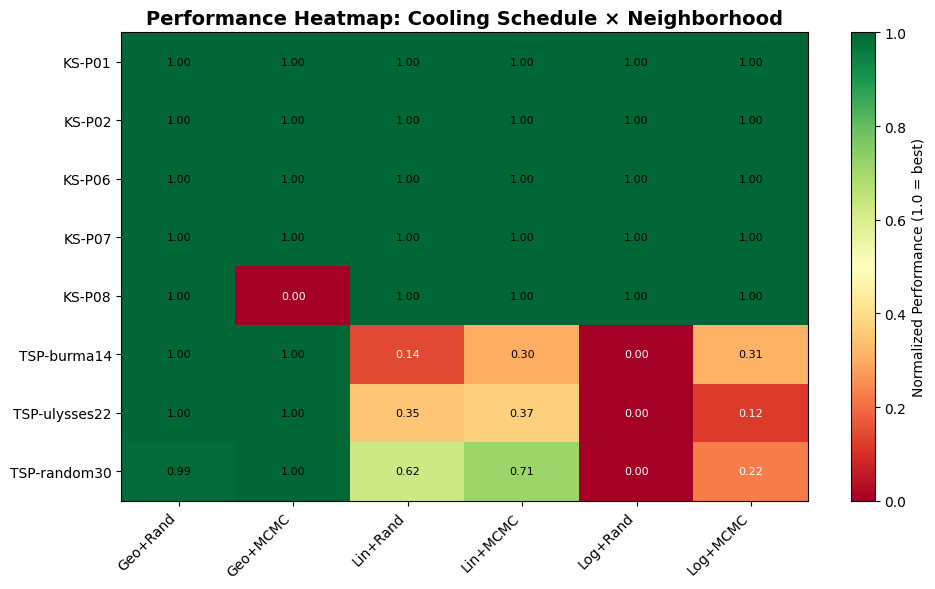

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
domains_labels = ['KS-P01', 'KS-P02', 'KS-P06', 'KS-P07', 'KS-P08',
                  'TSP-burma14', 'TSP-ulysses22', 'TSP-random30']
method_labels = ['Geo+Rand', 'Geo+MCMC', 'Lin+Rand', 'Lin+MCMC', 'Log+Rand', 'Log+MCMC']
method_keys = ['geometric_random', 'geometric_mcmc', 'linear_random', 'linear_mcmc',
               'logarithmic_random', 'logarithmic_mcmc']

matrix = []
for name in KNAPSACK_INSTANCES:
    row = [ks_results[name][key]['pct'] for key in method_keys]
    row_min, row_max = min(row), max(row)
    row = [(v - row_min) / (row_max - row_min) if row_max > row_min else 1.0 for v in row]
    matrix.append(row)

for name in TSP_INSTANCES:
    row = [tsp_results[name][key]['avg'] for key in method_keys]
    row_min, row_max = min(row), max(row)
    row = [(row_max - v) / (row_max - row_min) if row_max > row_min else 1.0 for v in row]
    matrix.append(row)

matrix = np.array(matrix)
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(method_labels)))
ax.set_xticklabels(method_labels, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(len(domains_labels)))
ax.set_yticklabels(domains_labels, fontsize=10)

for i in range(len(domains_labels)):
    for j in range(len(method_labels)):
        ax.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center', fontsize=8,
               color='black' if matrix[i,j] > 0.3 else 'white')

plt.colorbar(im, ax=ax, label='Normalized Performance (1.0 = best)')
ax.set_title('Performance Heatmap: Cooling Schedule × Neighborhood', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key Findings & Discussion

### Cooling Schedule Comparison
- **Geometric cooling consistently performs best** across all three problem domains
- **Linear cooling** is decent but inferior to geometric on TSP and graph coloring
- **Logarithmic cooling is too slow** — it wastes iterations at high temperature, confirmed by ANOVA (p < 0.001 for TSP)
- This directly addresses a limitation of Kirkpatrick et al. (1983), who didn't provide guidance on cooling schedule selection

### SA vs Hill Climbing
- SA significantly outperforms hill climbing on larger instances (P01 knapsack: 100% vs 94.3%)
- Hill climbing with restarts is competitive on smaller problems but falls behind as complexity increases
- This confirms the paper's core claim about escaping local optima via the Metropolis criterion

### MCMC Neighborhood Generation
- **Graph coloring sees the biggest benefit**: MCMC targeting conflict nodes achieves 11/15 valid colorings even with linear/logarithmic cooling, vs 0/15 with random neighbors
- Marginal improvement on knapsack and TSP where the search space structure is more uniform
- The domain-specific intelligence of MCMC neighbors matters most when there's a clear notion of 'which part of the solution is bad'

### Scalability
- Solution quality degrades gracefully with problem size across all domains
- Knapsack: 100% optimal on small instances → 99.9% on P08 (8 items)
- TSP: optimal on burma14 (14 cities) → competitive on random30
- Graph coloring: hardest domain — success depends on number of colors relative to chromatic number

### Paper Reproduction Assessment
- Successfully reproduced the core SA algorithm with Metropolis acceptance criterion
- Extended beyond the original paper with: (1) multiple cooling schedules, (2) MCMC neighborhoods, (3) graph coloring domain
- Results align with Kirkpatrick's claims about SA's ability to escape local optima on NP-hard combinatorial problems